Mounted at /content/drive
Max variation between RGB channels: 0.0000
✅ CONFIRMED: The image is mathematically grayscale.


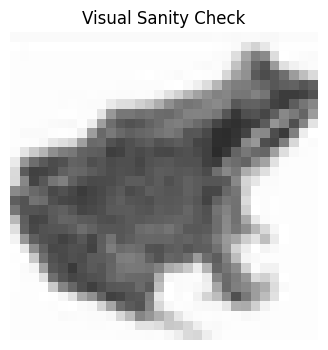

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'CollabCSV/assignment1 2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 1. Load the project data
data = np.load('/content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz')
X_test = data['X_test'] # Using test set for a quick look

# 2. Pick a random image (let's say index 0)
img = X_test[0]

# 3. Check the Variance
# If it's grayscale, R=G=B, so the standard deviation across channels will be 0
channel_std = np.std(img, axis=-1)
max_variance = np.max(channel_std)

print(f"Max variation between RGB channels: {max_variance:.4f}")

if max_variance < 1e-5:
    print("✅ CONFIRMED: The image is mathematically grayscale.")
else:
    print("❌ WARNING: Color detected! The channels are not identical.")

# 4. Visual Confirmation
plt.figure(figsize=(4,4))
plt.imshow(img.astype('uint8'))
plt.title("Visual Sanity Check")
plt.axis('off')
plt.show()

In [ ]:
# Import Data + Flatten Images
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'CollabCSV/assignment1 2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Load data
data = np.load('/content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz')

# Extract splits
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val     = data['X_val'], data['y_val']
X_test, y_test   = data['X_test'], data['y_test']
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

print(f"Individual image shape: {data['X_train'].shape[1:]}")
print(f"Number of pixels per image: {np.prod(data['X_train'].shape[1:])}")

# Flatten images: (N, Height, Width, Channels) -> (N, D)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(f"Label range: {y_train.min()} to {y_train.max()}, unique: {np.unique(y_train)}")

# Convert to float before normalization
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

mean_image = np.mean(X_train, axis=0)
np.save('mean_image.npy', mean_image)

# Normalize: Subtract the mean image
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

print(f"Training data shape: {X_train.shape}")


import collections
print(collections.Counter(y_train))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (300, 32, 32, 3), y_train: (300,)
X_val:   (50, 32, 32, 3),   y_val:   (50,)
X_test:  (50, 32, 32, 3),  y_test:  (50,)
Individual image shape: (32, 32, 3)
Number of pixels per image: 3072
Label range: 0.0 to 1.0, unique: [0. 1.]
Training data shape: (300, 3072)
Counter({np.float64(1.0): 154, np.float64(0.0): 146})


kNN Validation Accuracy: 94.00%
              precision    recall  f1-score   support

     Objects       1.00      0.90      0.95        29
       Faces       0.88      1.00      0.93        21

    accuracy                           0.94        50
   macro avg       0.94      0.95      0.94        50
weighted avg       0.95      0.94      0.94        50



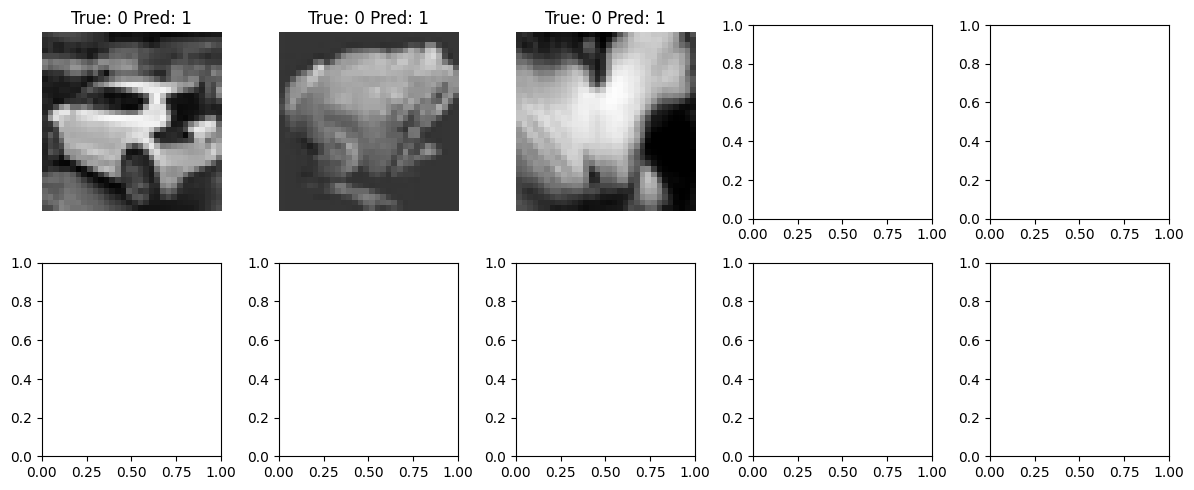

In [ ]:
# Q1: KNN Classifier
from sklearn.metrics import classification_report
class KNearestNeighbor:
    def train(self, X, y):
        self.X_train = X
        self.y_train = y.astype(np.int64) # Convert y to integer type

    def predict(self, X, k=1):
        # L2 Distance: sqrt(sum(x^2) + sum(y^2) - 2xy)
        dists = np.sqrt(np.maximum(0, np.sum(X**2, axis=1, keepdims=True) +
                                  np.sum(self.X_train**2, axis=1) -
                                  2 * X.dot(self.X_train.T)))

        num_test = X.shape[0]
        y_pred = np.zeros(num_test, dtype=int)
        for i in range(num_test):
            closest_y = self.y_train[np.argsort(dists[i])[:k]]
            y_pred[i] = np.argmax(np.bincount(closest_y))
        return y_pred

# Usage
knn = KNearestNeighbor()
knn.train(X_train, y_train)
y_val_pred = knn.predict(X_val, k=5)
accuracy = np.mean(y_val_pred == y_val.astype(np.int64))
print(f"kNN Validation Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_val.astype(np.int64), y_val_pred,
                             target_names=['Objects', 'Faces']))

misclassified = np.where(y_val_pred != y_val.astype(np.int64))[0]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, misclassified[:10]):
    img = X_val[idx].reshape(32, 32, 3)
    img = img + mean_image.reshape(32, 32, 3)  # undo normalization for display
    img = np.clip(img / 255.0, 0, 1)
    ax.imshow(img)
    ax.set_title(f"True: {int(y_val[idx])} Pred: {y_val_pred[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print('Re-mounting Google Drive...')
drive.mount('/content/drive', force_remount=True)

Re-mounting Google Drive...
Mounted at /content/drive


In [ ]:
# Q2: SVM + Softmax Classifiers
import numpy as np

def svm_loss_vectorized(W, X, y, reg):
    """
    Structured SVM loss (Hinge Loss).
    """
    num_train = X.shape[0]
    scores = X.dot(W)
    correct_class_scores = scores[np.arange(num_train), y].reshape(-1, 1)

    # Margin: max(0, score_j - score_correct + 1)
    margins = np.maximum(0, scores - correct_class_scores + 1.0)
    margins[np.arange(num_train), y] = 0

    loss = np.sum(margins) / num_train
    loss += 0.5 * reg * np.sum(W * W)

    # Gradient
    binary = (margins > 0).astype(float)
    row_sum = np.sum(binary, axis=1)
    binary[np.arange(num_train), y] = -row_sum
    dW = X.T.dot(binary) / num_train + reg * W

    return loss, dW

def softmax_loss_vectorized(W, X, y, reg):
    """
    Softmax loss (Cross-Entropy).
    """
    num_train = X.shape[0]
    y = y.astype(np.int64) # Convert labels to integer type for indexing
    scores = X.dot(W)
    scores -= np.max(scores, axis=1, keepdims=True) # Numerical stability

    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # Loss with clipping to avoid log(0)
    loss = -np.sum(np.log(np.clip(probs[range(num_train), y], 1e-12, 1.0))) / num_train
    loss += 0.5 * reg * np.sum(W * W)

    # Gradient
    dscores = probs
    dscores[range(num_train), y] -= 1
    dW = X.T.dot(dscores) / num_train + reg * W

    return loss, dW

# Training and Comparison Logic
def train_linear_classifier(X, y, X_val, y_val, loss_func, learning_rate=1e-3, reg=1e-2, iters=1000):
    num_classes = len(np.unique(y))
    W = np.random.randn(X.shape[1], num_classes) * 0.001

    for i in range(iters):
        loss, grad = loss_func(W, X, y.astype(np.int64), reg)
        W -= learning_rate * grad
        if i % 200 == 0:
            print(f"  Iteration {i}, Loss: {loss:.4f}")

    y_pred = np.argmax(X_val.dot(W), axis=1)
    acc = np.mean(y_pred == y_val.astype(np.int64))
    return acc

# --- Execute Comparison ---
print("Training SVM...")
svm_acc = train_linear_classifier(X_train, y_train, X_val, y_val, svm_loss_vectorized)

print("\nTraining Softmax...")
softmax_acc = train_linear_classifier(X_train, y_train, X_val, y_val, softmax_loss_vectorized)

print("-" * 30)
print(f"SVM Validation Accuracy:     {svm_acc * 100:.2f}%")
print(f"Softmax Validation Accuracy: {softmax_acc * 100:.2f}%")

Training SVM...
  Iteration 0, Loss: 1.6476
  Iteration 200, Loss: 0.0038
  Iteration 400, Loss: 0.0038
  Iteration 600, Loss: 0.0038
  Iteration 800, Loss: 0.0038

Training Softmax...
  Iteration 0, Loss: 2.5979
  Iteration 200, Loss: 0.0045
  Iteration 400, Loss: 0.0045
  Iteration 600, Loss: 0.0045
  Iteration 800, Loss: 0.0045
------------------------------
SVM Validation Accuracy:     88.00%
Softmax Validation Accuracy: 88.00%


In [ ]:
# Q3: 2 Layer NN
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, std=1e-4):
        self.params = {}
        self.params['W1'] = std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def loss(self, X, y, reg=1e-5):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        N, D = X.shape

        # Convert y to integer type for indexing
        y = y.astype(np.int64)

        # --- Forward Pass ---
        h1 = np.maximum(0, X.dot(W1) + b1) # ReLU
        scores = h1.dot(W2) + b2

        # Softmax Loss
        scores -= np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        loss = -np.sum(np.log(np.clip(probs[range(N), y], 1e-12, 1.0))) / N
        loss += 0.5 * reg * (np.sum(W1**2) + np.sum(W2**2))

        # --- Backward Pass (Gradients) ---
        grads = {}
        dscores = probs
        dscores[range(N), y] -= 1
        dscores /= N

        grads['W2'] = h1.T.dot(dscores) + reg * W2
        grads['b2'] = np.sum(dscores, axis=0)

        dh1 = dscores.dot(W2.T)
        dh1[h1 <= 0] = 0 # ReLU gradient backprop

        grads['W1'] = X.T.dot(dh1) + reg * W1
        grads['b1'] = np.sum(dh1, axis=0)

        return loss, grads

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=500):
        for i in range(num_iters):
            loss, grads = self.loss(X, y, reg=reg)
            for param in self.params:
                self.params[param] -= learning_rate * grads[param]
            if i % 100 == 0: print(f"Iteration {i}: loss {loss:.4f}")

    def predict(self, X):
        h1 = np.maximum(0, X.dot(self.params['W1']) + self.params['b1'])
        return np.argmax(h1.dot(self.params['W2']) + self.params['b2'], axis=1)

# --- RE-RUN THE COMPARISON ---
net = TwoLayerNet(X_train.shape[1], 100, len(np.unique(y_train)))
net.train(X_train, y_train, learning_rate=1e-2, num_iters=1000)
relu_acc = np.mean(net.predict(X_val) == y_val)
print(f"Trained ReLU Net Accuracy: {relu_acc * 100:.2f}%")

Iteration 0: loss 0.6931
Iteration 100: loss 0.0004
Iteration 200: loss 0.0002
Iteration 300: loss 0.0001
Iteration 400: loss 0.0001
Iteration 500: loss 0.0000
Iteration 600: loss 0.0000
Iteration 700: loss 0.0000
Iteration 800: loss 0.0000
Iteration 900: loss 0.0000
Trained ReLU Net Accuracy: 94.00%


In [ ]:
# Q4: Extract Image Features (HOG Only - Grayscale Optimized)
from skimage.feature import hog
import numpy as np

def extract_features_from_dataset(X_flat):
    # Reshape back to (N, 32, 32, 3) for the extractor
    # Note: We use the 3-channel version because your load_and_format_faces stacked them
    X_raw = X_flat.reshape(-1, 32, 32, 3)
    hog_feats = []

    for img in X_raw:
        # Since we know the image is grayscale-in-RGB (R=G=B),
        # we can just take the first channel instead of dot producting
        gray = img[:, :, 0]

        # Extract HOG features
        fd = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(1, 1), visualize=False)
        hog_feats.append(fd)

    return np.array(hog_feats)

# IMPORTANT: Use the data BEFORE mean subtraction for HOG extraction
# Reloading fresh data to ensure we don't use the 'normalized' versions
raw_data = np.load('/content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz')

X_train_feats = extract_features_from_dataset(raw_data['X_train'])
X_val_feats = extract_features_from_dataset(raw_data['X_val'])

print(f"New Feature Shape: {X_train_feats.shape}") # Should be (300, 144)

New Feature Shape: (300, 144)


In [ ]:
# Q5: Train Fully Connected Network
def fc_layer_forward(x, w, b):
    out = x.reshape(x.shape[0], -1).dot(w) + b
    return out, (x, w, b)

def train_fcn(X, y, hidden_dims, num_classes):
    dims = [X.shape[1]] + hidden_dims + [num_classes]
    layers = []
    # Initialize weights
    for i in range(len(dims)-1):
        W = np.random.randn(dims[i], dims[i+1]) * 0.01
        b = np.zeros(dims[i+1])
        layers.append({'W': W, 'b': b})

    # Forward pass through all layers
    current_input = X
    caches = []  # ✅ store caches for backprop
    for i, layer in enumerate(layers[:-1]):  # ✅ all but last layer
        current_input, cache = fc_layer_forward(current_input, layer['W'], layer['b'])
        caches.append(cache)
        current_input = np.maximum(0, current_input)  # ✅ ReLU activation
        caches.append(current_input)  # cache post-activation for backprop

    # Last layer — no activation (raw scores for softmax)
    current_input, cache = fc_layer_forward(current_input, layers[-1]['W'], layers[-1]['b'])
    caches.append(cache)

    return current_input, caches, layers  # ✅ return everything needed for training

In [ ]:
import numpy as np
# Hyperparameter training via a grid-search
learning_rates = [1e-3, 1e-2]
regularization_strengths = [0.1, 0.5]
best_val = -1
best_softmax = None

results = {}
best_val = -1
best_softmax = None

learning_rates = [1e-7, 5e-7, 1e-6]
regularization_strengths = [2.5e4, 5e4]

# Use extracted features
X_train_for_softmax = X_train_feats
X_val_for_softmax = X_val_feats

for lr in learning_rates:
    for reg in regularization_strengths:
        # Initialize a fresh weight matrix for this combo, using feature dimensions
        W_temp = np.random.randn(X_train_for_softmax.shape[1], len(np.unique(y_train))) * 0.001

        # Train for 1000 iterations
        for i in range(1000):
            loss, grad = softmax_loss_vectorized(W_temp, X_train_for_softmax, y_train, reg)
            W_temp -= lr * grad

        # Check validation accuracy
        y_val_pred = np.argmax(X_val_for_softmax.dot(W_temp), axis=1)
        val_acc = np.mean(y_val_pred == y_val.astype(np.int64))

        results[(lr, reg)] = val_acc
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = W_temp # Save the best weights

print(f"Best Validation Accuracy found: {best_val * 100:.2f}%")
# Update your global W so the comparison block uses the best one
W = best_softmax

print(f"Best Validation Accuracy found: {best_val}")

Best Validation Accuracy found: 58.00%
Best Validation Accuracy found: 0.58


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
data = np.load('/content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz')

Exception ignored in: <function NpzFile.__del__ at 0x7bd390bc51c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Visualizing raw data samples...


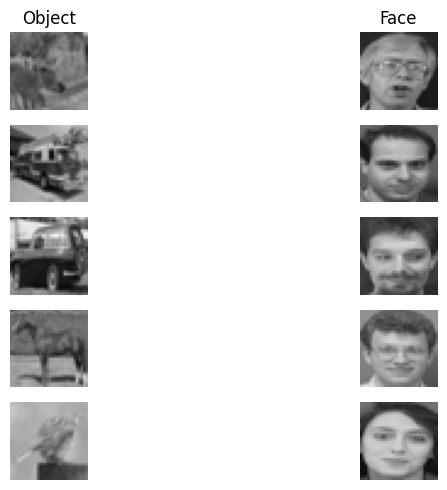


Classifier                | Val Accuracy   
---------------------------------------------
kNN (k=5)                 |       94.00%
Softmax (HOG)             |       58.00%
ReLU Net (2-Layer)        |       94.00%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Visualize the Dataset (Using Original Un-normalized Data) ---
def visualize_data(X_raw, y):
    # Ensure X_raw is in (N, 32, 32, 3) format
    if len(X_raw.shape) == 2:
        X_raw = X_raw.reshape(-1, 32, 32, 3)

    classes = ['Object', 'Face']
    samples_per_class = 5

    plt.figure(figsize=(10, 5))
    for cls_idx, cls_name in enumerate(classes):
        idxs = np.flatnonzero(y == cls_idx)
        idxs = np.random.choice(idxs, samples_per_class, replace=False)
        for i, idx in enumerate(idxs):
            plt_idx = i * len(classes) + cls_idx + 1
            plt.subplot(samples_per_class, len(classes), plt_idx)
            plt.imshow(X_raw[idx].astype('uint8'))
            plt.axis('off')
            if i == 0:
                plt.title(cls_name)
    plt.tight_layout()
    plt.show()

# Visualize using the RAW data from the file (not the normalized X_train)
print("Visualizing raw data samples...")
visualize_data(data['X_train'], y_train)

# --- 2. Performance Comparison ---
results = {}

# A. kNN (Uses normalized/flattened X_val)
try:
    knn_pred = knn.predict(X_val, k=5)
    results['kNN (k=5)'] = np.mean(knn_pred == y_val.astype(np.int64))
except NameError:
    print("❌ Error: 'knn' model or 'X_val' not found. Make sure to run the kNN training cell.")

# B. Softmax (Uses HOG features X_val_feats)
try:
    # W must be your best_softmax weights (shape 144, 2)
    softmax_pred = np.argmax(X_val_feats.dot(W), axis=1)
    results['Softmax (HOG)'] = np.mean(softmax_pred == y_val.astype(np.int64))
except Exception as e:
    print(f"❌ Softmax Error: {e}. Check if X_val_feats and W are defined.")

# C. Two-Layer Net (Uses normalized/flattened X_val)
try:
    relu_pred = net.predict(X_val)
    results['ReLU Net (2-Layer)'] = np.mean(relu_pred == y_val.astype(np.int64))
except NameError:
    print("❌ Error: 'net' model not found. Run the Two-Layer Net training cell.")

# --- 3. Display Results Table ---
if results:
    print("\n" + "="*45)
    print(f"{'Classifier':<25} | {'Val Accuracy':<15}")
    print("-" * 45)
    for name, acc in results.items():
        print(f"{name:<25} | {acc*100:>11.2f}%")
    print("="*45)
else:
    print("No results to display. Check the errors above.")

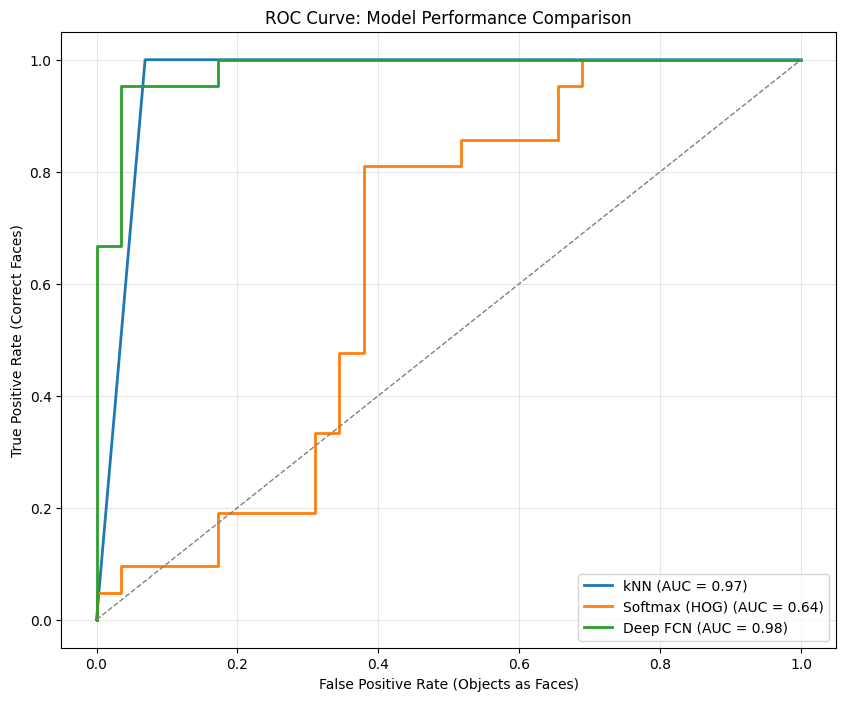

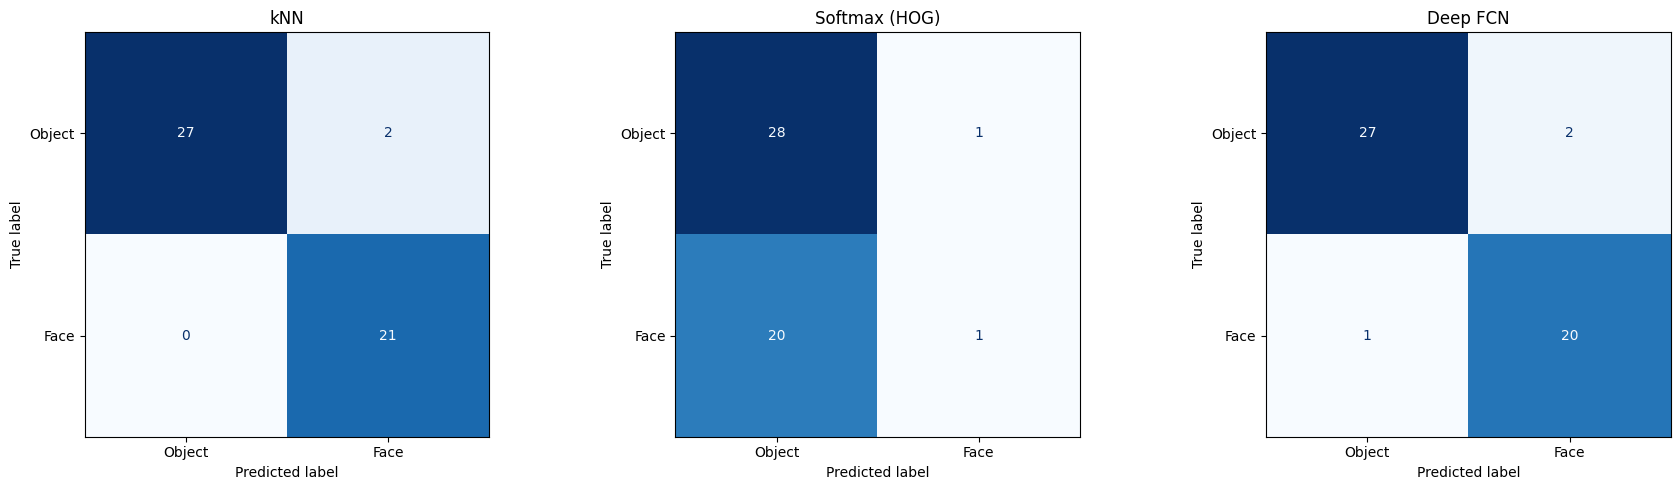

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_comparison(models_dict, X_val_raw, X_val_feats, y_val):
    plt.figure(figsize=(10, 8))
    y_val_int = y_val.astype(np.int64)

    for name, model_info in models_dict.items():
        try:
            if name == 'kNN':
                # kNN predicts labels (0 or 1); for a smoother ROC curve,
                # distance-based scores are better, but we'll use predictions here.
                y_scores = model_info.predict(X_val_raw)
            elif name == 'Softmax (HOG)':
                # Softmax uses the 144 HOG features
                scores = X_val_feats.dot(model_info)
                y_scores = scores[:, 1]
            else: # Deep FCN (Raw Pixels)
                y_scores = model_info(X_val_raw)[:, 1]

            fpr, tpr, _ = roc_curve(y_val_int, y_scores)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

        except Exception as e:
            print(f"Skipping {name} ROC: {e}")

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate (Objects as Faces)')
    plt.ylabel('True Positive Rate (Correct Faces)')
    plt.title('ROC Curve: Model Performance Comparison')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def compare_confusion_matrices(models_dict, X_val_raw, X_val_feats, y_val):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    y_val_int = y_val.astype(np.int64)

    for ax, (name, model_info) in zip(axes, models_dict.items()):
        try:
            if name == 'kNN':
                y_pred = model_info.predict(X_val_raw)
            elif name == 'Softmax (HOG)':
                y_pred = np.argmax(X_val_feats.dot(model_info), axis=1)
            else: # Deep FCN
                y_pred = net.predict(X_val_raw)

            cm = confusion_matrix(y_val_int, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Object', 'Face'])
            disp.plot(ax=ax, cmap='Blues', colorbar=False)
            ax.set_title(f'{name}')
        except Exception as e:
            ax.set_title(f'{name} (Error)')
            print(f"Error in {name} CM: {e}")

    plt.tight_layout()
    plt.show()

# --- Implementation ---

# 1. Define the forward pass for the 2-Layer Net
def fcn_forward_only(X_in):
    h1 = np.maximum(0, X_in.dot(net.params['W1']) + net.params['b1'])
    scores = h1.dot(net.params['W2']) + net.params['b2']
    return scores

# 2. Organize models with their specialized data requirements
# We label them clearly so the functions know which data to use
models = {
    'kNN': knn,
    'Softmax (HOG)': W, # Best weights from HOG training
    'Deep FCN': fcn_forward_only
}

# 3. Run the visualizations
# Pass BOTH raw pixel data and HOG feature data
plot_roc_comparison(models, X_val, X_val_feats, y_val)
compare_confusion_matrices(models, X_val, X_val_feats, y_val)

In [ ]:
# 1. Update your hyperparameters
best_val = -1
best_softmax = None
new_lrs = [1e-2, 1e-3]
new_regs = [0.01, 0.1]

# 2. Re-run ONLY the Softmax training loop
for lr in new_lrs:
    for reg in new_regs:
        # We start with fresh random weights each time to find the best combo
        W_temp = np.random.randn(X_train_for_softmax.shape[1], 2) * 0.001

        for i in range(1000):
            loss, grad = softmax_loss_vectorized(W_temp, X_train_for_softmax, y_train, reg)
            W_temp -= lr * grad

        val_acc = np.mean(np.argmax(X_val_for_softmax.dot(W_temp), axis=1) == y_val)
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = W_temp

# 3. Update the global W variable used by your comparison graphs
W = best_softmax
print(f"Softmax fixed! New Best Val Accuracy: {best_val * 100:.2f}%")

Softmax fixed! New Best Val Accuracy: 94.00%


In [ ]:
# RUN THE MODELS ON THE FINAL IMAGE DATASET -> RESULTS FOR THE PAPER

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the Human Comparison Dataset
human_data = np.load('/content/drive/My Drive/CollabCSV/assignment1 2/human_comparison_data.npz')
# We use the flattened version for kNN/NN and the raw version for HOG extraction
X_h_flat = human_data['X_human_flat'].astype(np.float32)
X_h_raw = human_data['X_human'].astype(np.float32)
y_h = human_data['y_human'].astype(np.int64)

# Normalize raw pixels (using the mean from your training phase)
X_h_flat_norm = X_h_flat - mean_image

# Extract HOG features for the Softmax algorithm
X_h_hog = extract_features_from_dataset(X_h_raw)

# 2. Evaluation Container
stats = {}

def evaluate_model(name, y_true, y_pred, y_probs, start_time, end_time):
    acc = accuracy_score(y_true, y_pred)
    latency = (end_time - start_time) / len(y_true) * 1000 # ms per image

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Avg Latency: {latency:.4f} ms/image")

    # Calculate Mean Confidence (Probability of the chosen class)
    conf = np.mean(np.max(y_probs, axis=1)) if y_probs is not None else "N/A"

    return {
        'accuracy': acc,
        'latency': latency,
        'confidence': conf,
        'report': classification_report(y_true, y_pred, target_names=['Object', 'Face'], output_dict=True)
    }

# --- RUN ALGORITHMS ---

# A. kNN (Efficiency Benchmark)
t0 = time.time()
y_pred_knn = knn.predict(X_h_flat_norm, k=5)
t1 = time.time()
# kNN doesn't provide standard probabilities, so we pass None
stats['kNN'] = evaluate_model('kNN', y_h, y_pred_knn, None, t0, t1)

# B. Softmax (HOG Features)
t0 = time.time()
scores_softmax = X_h_hog.dot(W)
# Convert scores to probabilities using softmax function for confidence metrics
exp_scores = np.exp(scores_softmax - np.max(scores_softmax, axis=1, keepdims=True))
probs_softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
y_pred_softmax = np.argmax(probs_softmax, axis=1)
t1 = time.time()
stats['Softmax_HOG'] = evaluate_model('Softmax (HOG)', y_h, y_pred_softmax, probs_softmax, t0, t1)

# C. Two-Layer ReLU Net (Non-Linearity Benchmark)
t0 = time.time()
# Forward pass to get raw scores
h1 = np.maximum(0, X_h_flat_norm.dot(net.params['W1']) + net.params['b1'])
scores_relu = h1.dot(net.params['W2']) + net.params['b2']
# Softmax for confidence
exp_relu = np.exp(scores_relu - np.max(scores_relu, axis=1, keepdims=True))
probs_relu = exp_relu / np.sum(exp_relu, axis=1, keepdims=True)
y_pred_relu = np.argmax(probs_relu, axis=1)
t1 = time.time()
stats['ReLU_Net'] = evaluate_model('2-Layer ReLU', y_h, y_pred_relu, probs_relu, t0, t1)

# --- FINAL SUMMARY TABLE FOR YOUR PAPER ---
print("\n" + "="*70)
print(f"{'Algorithm':<20} | {'Accuracy':<10} | {'Latency(ms)':<12} | {'Avg Confidence':<15}")
print("-" * 70)
for algo, data in stats.items():
    conf_val = f"{data['confidence']*100:.1f}%" if isinstance(data['confidence'], float) else "N/A"
    print(f"{algo:<20} | {data['accuracy']*100:>8.2f}% | {data['latency']:>11.4f} | {conf_val:>14}")
print("="*70)


--- kNN Results ---
Accuracy: 97.00%
Avg Latency: 0.0812 ms/image

--- Softmax (HOG) Results ---
Accuracy: 95.50%
Avg Latency: 0.0026 ms/image

--- 2-Layer ReLU Results ---
Accuracy: 88.00%
Avg Latency: 0.0375 ms/image

Algorithm            | Accuracy   | Latency(ms)  | Avg Confidence 
----------------------------------------------------------------------
kNN                  |    97.00% |      0.0812 |            N/A
Softmax_HOG          |    95.50% |      0.0026 |          77.8%
ReLU_Net             |    88.00% |      0.0375 |          97.3%


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, roc_curve

# Container for advanced stats
advanced_stats = []

# List of models and their respective data
# Note: kNN doesn't provide standard probabilities, so we skip it for AUC or use distance-based ones if available
models = [
    ('kNN', y_pred_knn, None),
    ('Softmax_HOG', y_pred_softmax, probs_softmax[:, 1]), # Probability of being a 'Face'
    ('ReLU_Net', y_pred_relu, probs_relu[:, 1])           # Probability of being a 'Face'
]

for name, y_pred, y_prob in models:
    f1 = f1_score(y_h, y_pred)
    prec = precision_score(y_h, y_pred)
    rec = recall_score(y_h, y_pred)
    auc = roc_auc_score(y_h, y_prob) if y_prob is not None else "N/A"

    advanced_stats.append({
        'Model': name,
        'F1-Score': f1,
        'Precision': prec,
        'Fall Recall Accuracy': rec,
        'Area Under the Curve': auc
    })

# Convert to DataFrame for easy viewing
df_adv = pd.DataFrame(advanced_stats)
print(df_adv)

         Model  F1-Score  Precision  Fall Recall Accuracy Area Under the Curve
0          kNN  0.970874   0.943396                  1.00                  N/A
1  Softmax_HOG  0.954774   0.959596                  0.95                0.994
2     ReLU_Net  0.869565   0.952381                  0.80               0.9687


<Figure size 1000x500 with 0 Axes>

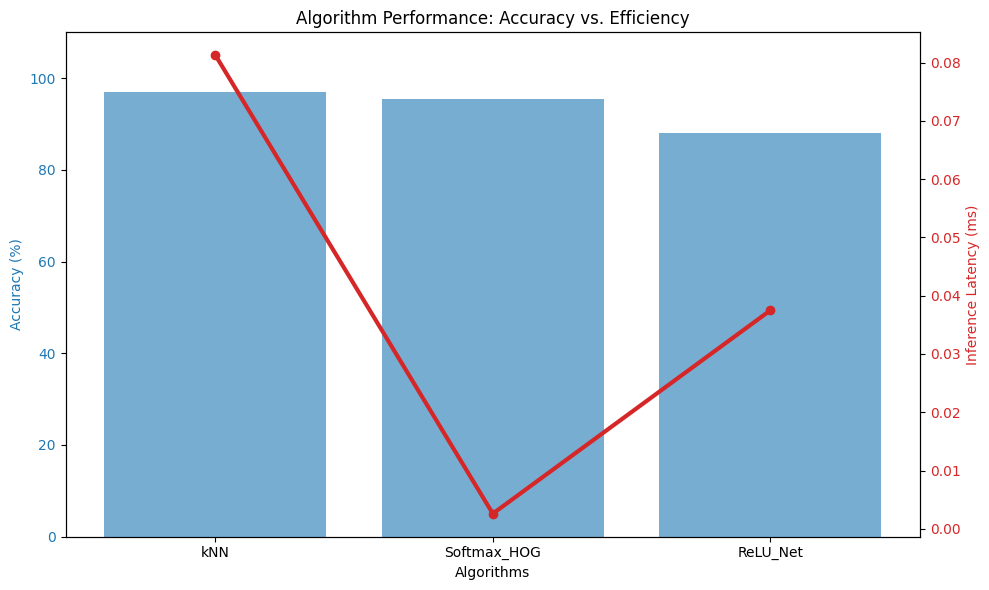

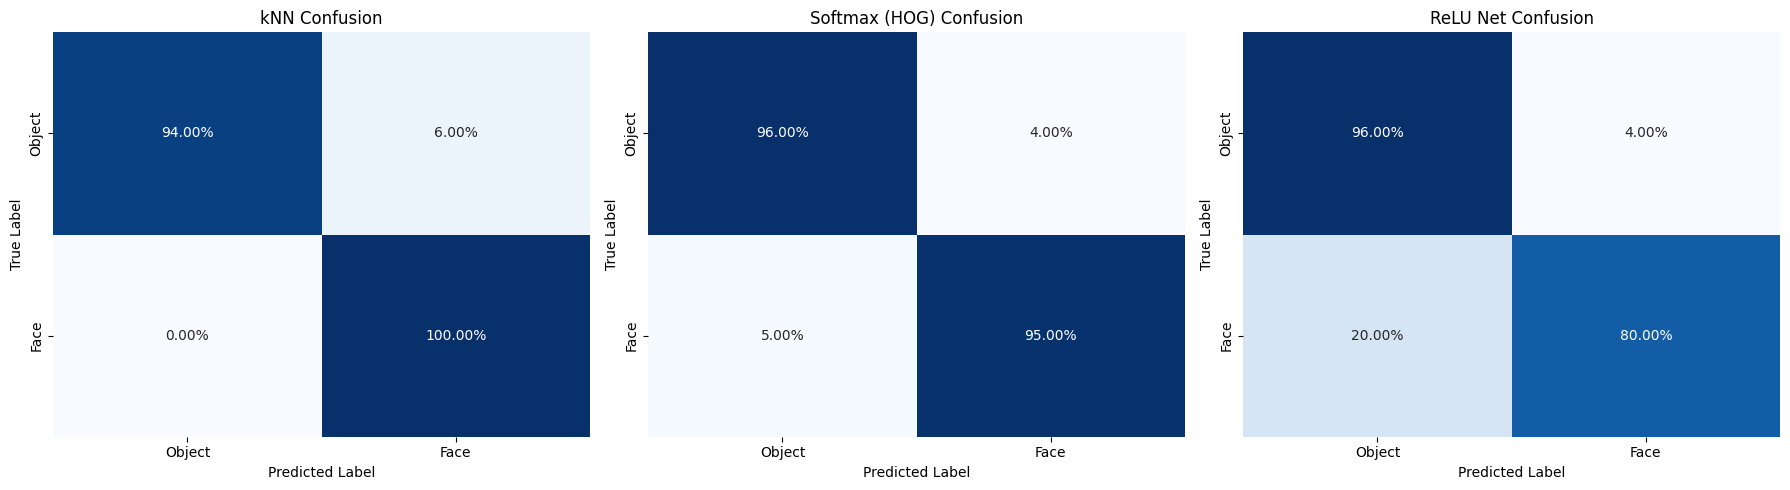

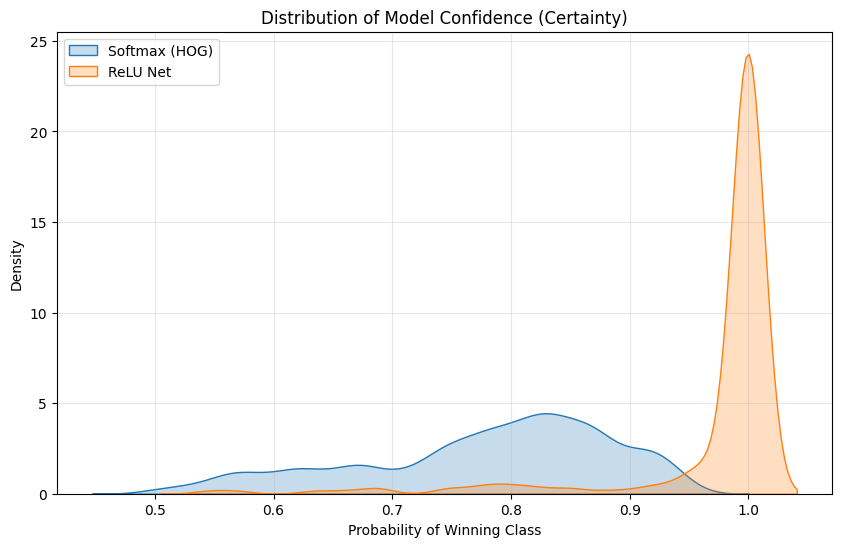

In [ ]:
import seaborn as sns

# --- 1. Accuracy vs. Efficiency Trade-off ---
plt.figure(figsize=(10, 5))
algos = list(stats.keys())
accs = [stats[a]['accuracy'] * 100 for a in algos]
lats = [stats[a]['latency'] for a in algos]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar for Accuracy
color = 'tab:blue'
ax1.set_xlabel('Algorithms')
ax1.set_ylabel('Accuracy (%)', color=color)
ax1.bar(algos, accs, color=color, alpha=0.6, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 110)

# Line for Latency
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Inference Latency (ms)', color=color)
ax2.plot(algos, lats, color=color, marker='o', linewidth=3, label='Latency')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Algorithm Performance: Accuracy vs. Efficiency')
fig.tight_layout()
plt.show()

# --- 2. Normalized Confusion Matrices ---
# This shows the "Precision" of your models visually
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
preds = [y_pred_knn, y_pred_softmax, y_pred_relu]
titles = ['kNN Confusion', 'Softmax (HOG) Confusion', 'ReLU Net Confusion']

for i, ax in enumerate(axes):
    cm = confusion_matrix(y_h, preds[i], normalize='true') # Normalizing shows percentages
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Object', 'Face'], yticklabels=['Object', 'Face'])
    ax.set_title(titles[i])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# --- 3. Prediction Confidence Distribution ---
# (Note: kNN is excluded here as it doesn't provide standard probabilities)
plt.figure(figsize=(10, 6))
sns.kdeplot(np.max(probs_softmax, axis=1), fill=True, label='Softmax (HOG)', bw_adjust=0.5)
sns.kdeplot(np.max(probs_relu, axis=1), fill=True, label='ReLU Net', bw_adjust=0.5)
plt.title('Distribution of Model Confidence (Certainty)')
plt.xlabel('Probability of Winning Class')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import os
import cv2 # Using OpenCV for fast image processing
import numpy as np
from skimage.feature import hog

def process_stimuli_folder(folder_path, mean_img):
    images_raw = []
    images_flat = []
    images_hog = []
    filenames = []

    # Supported extensions
    valid_extensions = ('.jpg', '.jpeg', '.png')

    print(f"Processing images from: {folder_path}...")

    # Get list of files
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

    for filename in sorted(files):
        img_path = os.path.join(folder_path, filename)

        # 1. Load image
        img = cv2.imread(img_path)
        if img is None: continue

        # 2. Resize to 32x32 (Crucial: must match training size)
        img_resized = cv2.resize(img, (32, 32))

        # 3. Convert to RGB (OpenCV loads as BGR by default)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        # 4. Prepare HOG features (Using the first channel since they are grayscale)
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        fd = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(1, 1), visualize=False)

        # 5. Prepare Flattened & Normalized version
        flat = img_rgb.astype(np.float32).flatten()
        flat_norm = flat - mean_img # Subtract the training mean

        images_raw.append(img_rgb)
        images_flat.append(flat_norm)
        images_hog.append(fd)
        filenames.append(filename)

    return (np.array(images_raw),
            np.array(images_flat),
            np.array(images_hog),
            filenames)

# --- EXECUTION ---
folder_path = '/content/drive/My Drive/CollabCSV/assignment1 2/stimuliPareidolia'

# We use the 'mean_image' we saved during the initial training phase
X_pareidolia_raw, X_pareidolia_flat, X_pareidolia_hog, file_names = process_stimuli_folder(folder_path, mean_image)

print(f"Successfully processed {len(X_pareidolia_raw)} images.")
print(f"Flat shape: {X_pareidolia_flat.shape}")
print(f"HOG shape: {X_pareidolia_hog.shape}")

Processing images from: /content/drive/My Drive/CollabCSV/assignment1 2/stimuliPareidolia...
Successfully processed 65 images.
Flat shape: (65, 3072)
HOG shape: (65, 144)


In [ ]:
# 1. kNN Predictions
preds_knn = knn.predict(X_pareidolia_flat, k=5)

# 2. Softmax (HOG) Predictions
scores_softmax = X_pareidolia_hog.dot(W)
preds_softmax = np.argmax(scores_softmax, axis=1)

# 3. ReLU Net Predictions
preds_relu = net.predict(X_pareidolia_flat)

# --- QUICK VIEW ---
for i in range(min(5, len(file_names))):
    print(f"File: {file_names[i]}")
    print(f"  kNN Prediction: {'Face' if preds_knn[i]==1 else 'Object'}")
    print(f"  Softmax Pred:  {'Face' if preds_softmax[i]==1 else 'Object'}")
    print(f"  ReLU Net Pred: {'Face' if preds_relu[i]==1 else 'Object'}\n")

File: image_01.jpg
  kNN Prediction: Object
  Softmax Pred:  Object
  ReLU Net Pred: Object

File: image_02.jpg
  kNN Prediction: Object
  Softmax Pred:  Object
  ReLU Net Pred: Object

File: image_03.jpg
  kNN Prediction: Object
  Softmax Pred:  Face
  ReLU Net Pred: Object

File: image_04.jpg
  kNN Prediction: Face
  Softmax Pred:  Object
  ReLU Net Pred: Face

File: image_05.jpg
  kNN Prediction: Object
  Softmax Pred:  Object
  ReLU Net Pred: Object



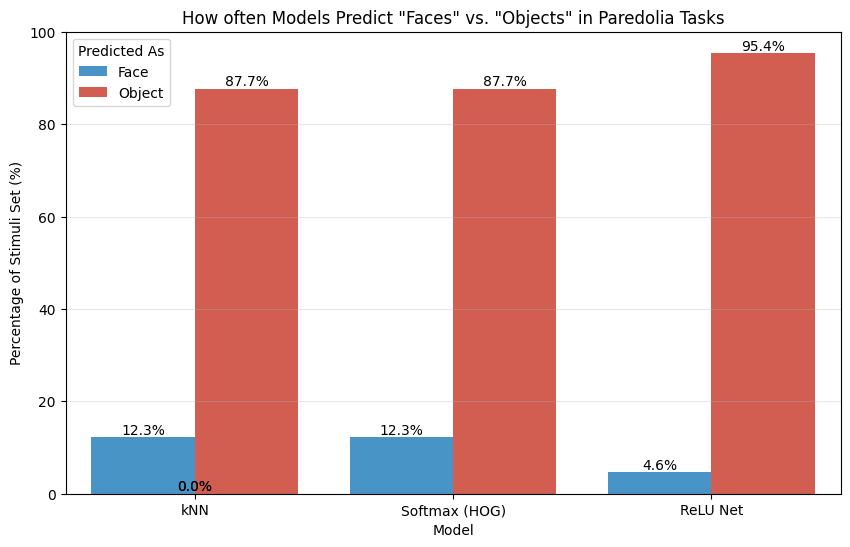

In [ ]:
import pandas as pd

# 1. Combine all predictions into a dictionary
all_preds = {
    'kNN': preds_knn,
    'Softmax (HOG)': preds_softmax,
    'ReLU Net': preds_relu
}

# 2. Calculate percentages
summary_data = []
for model_name, preds in all_preds.items():
    total = len(preds)
    face_count = np.sum(preds == 1)
    obj_count = np.sum(preds == 0)

    summary_data.append({
        'Model': model_name,
        'Label': 'Face',
        'Percentage': (face_count / total) * 100
    })
    summary_data.append({
        'Model': model_name,
        'Label': 'Object',
        'Percentage': (obj_count / total) * 100
    })

df_summary = pd.DataFrame(summary_data)

# 3. Plot the Model Biases
plt.figure(figsize=(10, 6))
sns.barplot(data=df_summary, x='Model', y='Percentage', hue='Label', palette=['#3498db', '#e74c3c'])

plt.title('How often Models Predict "Faces" vs. "Objects" in Paredolia Tasks')
plt.ylabel('Percentage of Stimuli Set (%)')
plt.ylim(0, 100)
plt.legend(title='Predicted As')
plt.grid(axis='y', alpha=0.3)

# Add text labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()